# Generalización entre lagos
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook evalúa si un modelo entrenado en un lago puede predecir la presencia de cianobacteria en el otro lago. Es una prueba de transferencia más exigente que la validación espacial del notebook 06: allí los bloques de validación eran zonas nuevas dentro del mismo cuerpo de agua, mientras que aquí el modelo se aplica a un lago con otra morfología, otro nivel de eutrofización y otro rango de valores espectrales.

**Contenido:**
1. Carga de datos
2. Submuestreo estratificado por lago
3. Conjunto de predictoras utilizable entre lagos
4. Protocolo de entrenamiento y evaluación
5. Experimento A: entrenar en Atitlán, evaluar en Amatitlán (7.1)
6. Experimento B: entrenar en Amatitlán, evaluar en Atitlán (7.2)
7. Métricas de ambos experimentos (7.3)
8. Comparación con entrenamiento y prueba del mismo lago (7.4)
9. Efecto de incluir las coordenadas como predictoras
10. Diferencias entre lagos que explican los resultados (7.6)
11. ¿Puede un modelo entrenado en un lago generalizar al otro? (7.5)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

np.random.seed(42)
Path('./data').mkdir(exist_ok=True)

## 1. Carga de datos

Se parte de la misma matriz de predictoras y de la misma variable respuesta usadas en los notebooks 04, 05 y 06, junto con la columna `lago` del dataset con metadatos.

In [2]:
X = pd.read_parquet('./data/X_predictoras.parquet')
y = pd.read_parquet('./data/y_respuesta.parquet').squeeze()
meta = pd.read_parquet('./data/dataset_ml_con_respuesta.parquet',
                       columns=['lago', 'fecha', 'lon', 'lat'])
meta['lago'] = meta['lago'].str.strip().str.lower()

print(f'Dataset completo: {len(X):,} observaciones x {X.shape[1]} variables')
print(f'Columnas: {list(X.columns)}')

resumen_lago = pd.DataFrame({
    'observaciones': meta.groupby('lago').size(),
    'clase 1': y.groupby(meta['lago'].values).sum(),
    '% clase 1': 100 * y.groupby(meta['lago'].values).mean(),
    'fechas': meta.groupby('lago')['fecha'].nunique()
})
print()
print(resumen_lago.round(2).to_string())

Dataset completo: 13,514,711 observaciones x 12 variables
Columnas: ['B03', 'B08', 'NDVI', 'NDWI', 'lon', 'lat', 'dist_centro_lago', 'mes_sin', 'mes_cos', 'epoca_lluviosa', 'brillo_B03_B08', 'lago_atitlan']



           observaciones  clase 1  % clase 1  fechas
amatitlan        1566557   175363      11.19      11
atitlan         11948154   125726       1.05      11


## 2. Submuestreo estratificado por lago

Atitlán aporta 11.9 millones de píxeles y Amatitlán 1.57 millones, es decir, Atitlán es casi 8 veces más grande. Para que los dos experimentos sean comparables entre sí y para que el costo de cómputo sea manejable, se toma de cada lago una **submuestra estratificada de hasta 2 millones de píxeles**, conservando exactamente la proporción de clase 1 del lago original.

Con esto:
- Amatitlán se usa completo (1.57 millones, por debajo del tope).
- De Atitlán se toma una submuestra aleatoria estratificada de 2 millones.
- Los dos experimentos entrenan con volúmenes de datos del mismo orden, de modo que las diferencias que se observen se deban al lago y no al tamaño de la muestra.

In [3]:
TOPE_POR_LAGO = 2_000_000

muestras = {}
for lago in ['atitlan', 'amatitlan']:
    idx_lago = meta.index[meta['lago'] == lago]
    if len(idx_lago) > TOPE_POR_LAGO:
        idx_sel, _ = train_test_split(
            idx_lago, train_size=TOPE_POR_LAGO,
            stratify=y.loc[idx_lago], random_state=42
        )
        idx_sel = pd.Index(idx_sel)
    else:
        idx_sel = idx_lago
    muestras[lago] = idx_sel
    print(f'{lago.capitalize()}: {len(idx_lago):,} disponibles -> '
          f'{len(idx_sel):,} usadas | clase 1: {y.loc[idx_sel].sum():,} '
          f'({100*y.loc[idx_sel].mean():.2f}%)')

Atitlan: 11,948,154 disponibles -> 2,000,000 usadas | clase 1: 21,045 (1.05%)
Amatitlan: 1,566,557 disponibles -> 1,566,557 usadas | clase 1: 175,363 (11.19%)


## 3. Conjunto de predictoras utilizable entre lagos

El conjunto definido en el notebook 03 incluye `lon`, `lat` y la variable indicadora `lago_atitlan`. Ninguna de las tres sirve para transferir un modelo de un lago al otro:

- **`lago_atitlan`** es constante dentro de cada lago. Si el modelo se entrena solo con Atitlán, la variable vale siempre 1 durante el entrenamiento y siempre 0 durante la evaluación, así que aporta cero información y además coloca a todas las observaciones de prueba fuera del rango visto.
- **`lon` y `lat`** ocupan rangos disjuntos en ambos lagos, ya que son cuerpos de agua separados por decenas de kilómetros. Un árbol entrenado con las coordenadas de un lago solo puede extrapolar cuando recibe las del otro, y todas las observaciones nuevas caen del mismo lado de cada corte aprendido.

Por eso los experimentos principales usan un conjunto de predictoras **transferible**: las bandas, los índices espectrales, la estacionalidad y `dist_centro_lago`, que es una distancia relativa al centro de cada lago y por lo tanto sí es comparable entre ambos. En la sección 8 se cuantifica qué pasa si se incluyen igualmente las coordenadas.

In [4]:
rangos = meta.groupby('lago')[['lon', 'lat']].agg(['min', 'max'])
print('Rangos de coordenadas por lago (UTM 15N, metros):')
print(rangos.round(0).to_string())

solape_lon = (min(rangos[('lon','max')]) - max(rangos[('lon','min')]))
solape_lat = (min(rangos[('lat','max')]) - max(rangos[('lat','min')]))
print(f'\nSolape en lon: {solape_lon:,.0f} m | Solape en lat: {solape_lat:,.0f} m')
print('(un valor negativo significa que los rangos no se solapan)')

Rangos de coordenadas por lago (UTM 15N, metros):
                lon                  lat           
                min       max        min        max
lago                                               
amatitlan  754575.0  768165.0  1594635.0  1603795.0
atitlan    680165.0  707735.0  1614285.0  1631675.0

Solape en lon: -46,840 m | Solape en lat: -10,490 m
(un valor negativo significa que los rangos no se solapan)


In [5]:
PREDICTORAS_TRANSFERIBLES = [
    'B03', 'B08', 'NDVI', 'NDWI',
    'dist_centro_lago',
    'mes_sin', 'mes_cos', 'epoca_lluviosa',
    'brillo_B03_B08'
]
PREDICTORAS_CON_COORDENADAS = PREDICTORAS_TRANSFERIBLES + ['lon', 'lat']

print(f'Predictoras transferibles ({len(PREDICTORAS_TRANSFERIBLES)}): {PREDICTORAS_TRANSFERIBLES}')
print(f'Excluidas para la transferencia: lon, lat, lago_atitlan')

Predictoras transferibles (9): ['B03', 'B08', 'NDVI', 'NDWI', 'dist_centro_lago', 'mes_sin', 'mes_cos', 'epoca_lluviosa', 'brillo_B03_B08']
Excluidas para la transferencia: lon, lat, lago_atitlan


## 4. Protocolo de entrenamiento y evaluación

Para cada lago:

1. Se divide su submuestra en 70 % entrenamiento y 30 % prueba, estratificando por la clase, igual que en el notebook 04.
2. Se entrenan los tres modelos (Regresión Logística, Random Forest y XGBoost) sobre el 70 % de ese lago, con los hiperparámetros seleccionados en el notebook 04.
3. El mismo modelo se evalúa dos veces: sobre el 30 % de prueba de su propio lago (referencia de mismo lago) y sobre la submuestra completa del otro lago (experimento de transferencia).

Usar el mismo modelo entrenado para las dos evaluaciones hace que la comparación del punto 7.4 sea directa: cambia únicamente el lago sobre el que se predice.

El desbalance se maneja como en el notebook 04, con `class_weight='balanced'` en Regresión Logística y Random Forest y `scale_pos_weight` en XGBoost, recalculado con la proporción de clases del lago de entrenamiento (11.19 % de positivos en Amatitlán frente a 1.05 % en Atitlán, así que el peso es muy distinto en cada caso).

In [6]:
def construir_modelos(scale_pos_weight):
    """Tres modelos con los hiperparámetros seleccionados en el notebook 04."""
    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.008263688714158009, solver='liblinear',
            class_weight='balanced', max_iter=1000, random_state=42))
    ])
    rf = RandomForestClassifier(
        n_estimators=137, max_depth=20, min_samples_leaf=2,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1)
    xgbc = xgb.XGBClassifier(
        n_estimators=156, learning_rate=0.1501725572054684, max_depth=5,
        subsample=0.8, colsample_bytree=1.0,
        reg_alpha=1.3145103232150122, reg_lambda=0.24400607090817547,
        scale_pos_weight=scale_pos_weight,
        random_state=42, eval_metric='auc', n_jobs=-1)
    return {'Regresión Logística': lr, 'Random Forest': rf, 'XGBoost': xgbc}


def evaluar(modelo, X_eval, y_eval):
    """Métricas del punto 5.1 con umbral 0.5, más PR-AUC y matriz de confusión."""
    y_pred = modelo.predict(X_eval)
    y_prob = modelo.predict_proba(X_eval)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()
    return {
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0),
        'F1-score': f1_score(y_eval, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_eval, y_prob),
        'PR-AUC': average_precision_score(y_eval, y_prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

In [7]:
# División 70/30 estratificada dentro de cada lago
particiones = {}
for lago, idx_lago in muestras.items():
    idx_tr, idx_te = train_test_split(
        idx_lago, test_size=0.30, stratify=y.loc[idx_lago], random_state=42
    )
    particiones[lago] = {'train': pd.Index(idx_tr), 'test': pd.Index(idx_te)}
    print(f'{lago.capitalize()}: train {len(idx_tr):,} '
          f'(clase 1: {100*y.loc[idx_tr].mean():.2f}%) | '
          f'test {len(idx_te):,} (clase 1: {100*y.loc[idx_te].mean():.2f}%)')

Atitlan: train 1,400,000 (clase 1: 1.05%) | test 600,000 (clase 1: 1.05%)


Amatitlan: train 1,096,589 (clase 1: 11.19%) | test 469,968 (clase 1: 11.19%)


In [8]:
# Entrenamiento de los tres modelos sobre cada lago
modelos_por_lago = {}

for lago in ['atitlan', 'amatitlan']:
    idx_tr = particiones[lago]['train']
    X_tr = X.loc[idx_tr, PREDICTORAS_TRANSFERIBLES]
    y_tr = y.loc[idx_tr]
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    print(f'\nEntrenando con {lago.capitalize()} '
          f'({len(X_tr):,} obs, scale_pos_weight = {spw:.2f})')

    modelos_por_lago[lago] = {}
    for nombre, modelo in construir_modelos(spw).items():
        t0 = time.time()
        modelo.fit(X_tr, y_tr)
        modelos_por_lago[lago][nombre] = modelo
        print(f'  {nombre}: entrenado en {time.time()-t0:.1f} s')


Entrenando con Atitlan (1,400,000 obs, scale_pos_weight = 94.03)


  Regresión Logística: entrenado en 1.7 s


  Random Forest: entrenado en 71.4 s


  XGBoost: entrenado en 4.5 s



Entrenando con Amatitlan (1,096,589 obs, scale_pos_weight = 7.93)


  Regresión Logística: entrenado en 2.4 s


  Random Forest: entrenado en 59.4 s


  XGBoost: entrenado en 3.2 s


## 5. Experimento A: entrenar en Atitlán, evaluar en Amatitlán (7.1)

Los modelos entrenados únicamente con píxeles de Atitlán se aplican a toda la submuestra de Amatitlán. Es el caso de un modelo calibrado en un lago oligotrófico grande y profundo que se lleva a un lago pequeño y eutrofizado.

In [9]:
resultados = []

for nombre, modelo in modelos_por_lago['atitlan'].items():
    idx_eval = muestras['amatitlan']
    m = evaluar(modelo, X.loc[idx_eval, PREDICTORAS_TRANSFERIBLES], y.loc[idx_eval])
    m.update({'Experimento': 'A: Atitlán -> Amatitlán', 'Modelo': nombre})
    resultados.append(m)
    print(f'{nombre}: Recall={m["Recall"]:.4f}  Precision={m["Precision"]:.4f}  '
          f'F1={m["F1-score"]:.4f}  ROC-AUC={m["ROC-AUC"]:.4f}')

df_A = pd.DataFrame([r for r in resultados if r['Experimento'].startswith('A')]).set_index('Modelo')
print('\nExperimento A (entrenado en Atitlán, evaluado en Amatitlán):')
print(df_A[['Accuracy','Precision','Recall','F1-score','ROC-AUC','PR-AUC']].round(4).to_string())

Regresión Logística: Recall=0.5254  Precision=0.2138  F1=0.3040  ROC-AUC=0.6952


Random Forest: Recall=0.2500  Precision=0.1308  F1=0.1717  ROC-AUC=0.5676


XGBoost: Recall=0.6364  Precision=0.1578  F1=0.2529  ROC-AUC=0.6502

Experimento A (entrenado en Atitlán, evaluado en Amatitlán):
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Modelo                                                                     
Regresión Logística    0.7306     0.2138  0.5254    0.3040   0.6952  0.1898
Random Forest          0.7301     0.1308  0.2500    0.1717   0.5676  0.1271
XGBoost                0.5790     0.1578  0.6364    0.2529   0.6502  0.2205


**Lectura del experimento A.** El desempeño cae de forma clara. Los ROC-AUC quedan entre 0.5676 y 0.6952, cuando estos mismos modelos alcanzan entre 0.9291 y 0.9829 dentro de Atitlán. Random Forest es el que peor transfiere (0.5676, apenas por encima del 0.5 que daría el azar) y XGBoost es el que más floraciones detecta (Recall 0.6364), pero marcando 595,713 píxeles como floración cuando no lo eran.

Hay que tener cuidado con una lectura ingenua de la tabla: Precision y F1 parecen mejores aquí que en la evaluación dentro de Atitlán. Eso no es una mejora del modelo, sino un efecto de la prevalencia. Amatitlán tiene 11.19 % de píxeles positivos y Atitlán solo 1.05 %, así que acertar por azar es diez veces más fácil en Amatitlán. La referencia correcta es el PR-AUC frente a la proporción de positivos del lago evaluado: 0.1898, 0.1271 y 0.2205 contra una línea base de 0.1119, es decir, entre 1.1 y 2.0 veces el azar. Es un margen muy pequeño.

## 6. Experimento B: entrenar en Amatitlán, evaluar en Atitlán (7.2)

El caso inverso: modelos calibrados en el lago con floraciones frecuentes y aplicados al lago donde la clase positiva es rara.

In [10]:
for nombre, modelo in modelos_por_lago['amatitlan'].items():
    idx_eval = muestras['atitlan']
    m = evaluar(modelo, X.loc[idx_eval, PREDICTORAS_TRANSFERIBLES], y.loc[idx_eval])
    m.update({'Experimento': 'B: Amatitlán -> Atitlán', 'Modelo': nombre})
    resultados.append(m)
    print(f'{nombre}: Recall={m["Recall"]:.4f}  Precision={m["Precision"]:.4f}  '
          f'F1={m["F1-score"]:.4f}  ROC-AUC={m["ROC-AUC"]:.4f}')

df_B = pd.DataFrame([r for r in resultados if r['Experimento'].startswith('B')]).set_index('Modelo')
print('\nExperimento B (entrenado en Amatitlán, evaluado en Atitlán):')
print(df_B[['Accuracy','Precision','Recall','F1-score','ROC-AUC','PR-AUC']].round(4).to_string())

Regresión Logística: Recall=0.9517  Precision=0.0121  F1=0.0239  ROC-AUC=0.8476


Random Forest: Recall=0.6727  Precision=0.0757  F1=0.1361  ROC-AUC=0.8585


XGBoost: Recall=0.8061  Precision=0.0184  F1=0.0360  ROC-AUC=0.7810

Experimento B (entrenado en Amatitlán, evaluado en Atitlán):
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Modelo                                                                     
Regresión Logística    0.1818     0.0121  0.9517    0.0239   0.8476  0.4349
Random Forest          0.9101     0.0757  0.6727    0.1361   0.8585  0.1355
XGBoost                0.5455     0.0184  0.8061    0.0360   0.7810  0.0944


**Lectura del experimento B.** En esta dirección el orden de las probabilidades sí conserva información: ROC-AUC entre 0.7810 y 0.8585, y PR-AUC de 0.4349 en la Regresión Logística frente a una línea base de 0.0105, unas 41 veces el azar.

Lo que se rompe es el punto de corte. Los modelos aprendieron en un lago donde 1 de cada 9 píxeles es positivo y se aplican a uno donde solo 1 de cada 95 lo es, así que sobrepredicen de forma masiva: la Regresión Logística marca 1,655,480 píxeles como floración cuando en realidad hay 21,045, y su Accuracy baja a 0.1818. La Precision queda entre 0.0121 y 0.0757 en los tres modelos.

## 7. Métricas de ambos experimentos (7.3)

In [11]:
df_cruzado = pd.DataFrame(resultados).set_index(['Experimento', 'Modelo'])
cols_metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']

print('Métricas de los dos experimentos de generalización entre lagos (umbral 0.5):')
print(df_cruzado[cols_metricas].round(4).to_string())
print()
print('Conteos de la matriz de confusión:')
print(df_cruzado[['TN', 'FP', 'FN', 'TP']].to_string())

Métricas de los dos experimentos de generalización entre lagos (umbral 0.5):
                                             Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Experimento             Modelo                                                                     
A: Atitlán -> Amatitlán Regresión Logística    0.7306     0.2138  0.5254    0.3040   0.6952  0.1898
                        Random Forest          0.7301     0.1308  0.2500    0.1717   0.5676  0.1271
                        XGBoost                0.5790     0.1578  0.6364    0.2529   0.6502  0.2205
B: Amatitlán -> Atitlán Regresión Logística    0.1818     0.0121  0.9517    0.0239   0.8476  0.4349
                        Random Forest          0.9101     0.0757  0.6727    0.1361   0.8585  0.1355
                        XGBoost                0.5455     0.0184  0.8061    0.0360   0.7810  0.0944

Conteos de la matriz de confusión:
                                                  TN       FP      FN      TP
Experimen

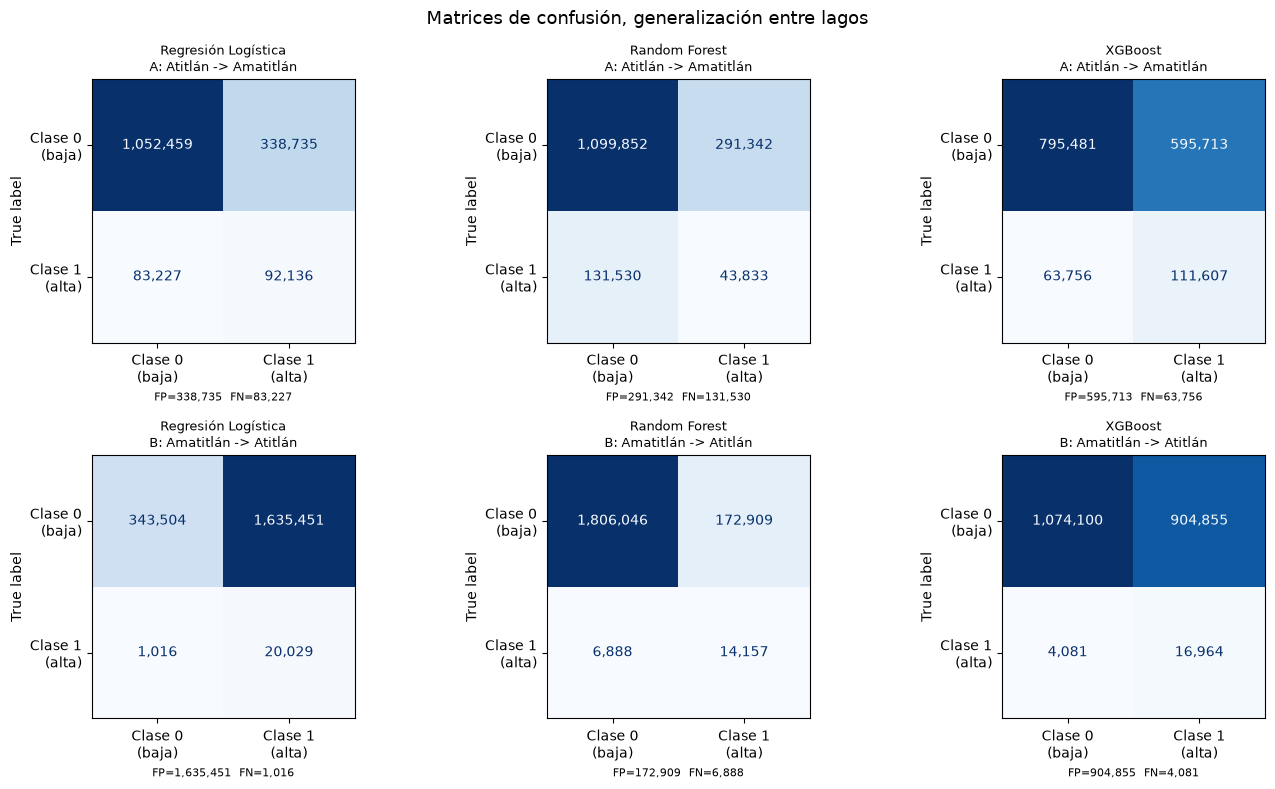

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, exp in enumerate(['A: Atitlán -> Amatitlán', 'B: Amatitlán -> Atitlán']):
    for j, nombre in enumerate(['Regresión Logística', 'Random Forest', 'XGBoost']):
        fila = df_cruzado.loc[(exp, nombre)]
        cm = np.array([[fila['TN'], fila['FP']], [fila['FN'], fila['TP']]], dtype=int)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['Clase 0\n(baja)', 'Clase 1\n(alta)'])
        disp.plot(ax=axes[i, j], colorbar=False, cmap='Blues', values_format=',d')
        axes[i, j].set_title(f'{nombre}\n{exp}', fontsize=9)
        axes[i, j].set_xlabel(f'FP={int(fila["FP"]):,}  FN={int(fila["FN"]):,}', fontsize=8)

plt.suptitle('Matrices de confusión, generalización entre lagos', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Comparación con entrenamiento y prueba del mismo lago (7.4)

Se evalúan los mismos modelos sobre el 30 % de prueba de su propio lago. La diferencia entre las dos columnas mide directamente el costo de cambiar de lago, sin que intervenga ningún otro cambio de configuración.

In [13]:
resultados_mismo = []
for lago in ['atitlan', 'amatitlan']:
    idx_te = particiones[lago]['test']
    for nombre, modelo in modelos_por_lago[lago].items():
        m = evaluar(modelo, X.loc[idx_te, PREDICTORAS_TRANSFERIBLES], y.loc[idx_te])
        m.update({'Experimento': f'Mismo lago: {lago.capitalize()}', 'Modelo': nombre})
        resultados_mismo.append(m)

df_mismo = pd.DataFrame(resultados_mismo).set_index(['Experimento', 'Modelo'])
print('Evaluación sobre el 30 % de prueba del propio lago:')
print(df_mismo[cols_metricas].round(4).to_string())

Evaluación sobre el 30 % de prueba del propio lago:
                                           Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Experimento           Modelo                                                                     
Mismo lago: Atitlan   Regresión Logística    0.8991     0.0805  0.8250    0.1468   0.9291  0.2803
                      Random Forest          0.9814     0.3334  0.7725    0.4658   0.9791  0.5469
                      XGBoost                0.9542     0.1781  0.9276    0.2989   0.9829  0.5714
Mismo lago: Amatitlan Regresión Logística    0.9190     0.5890  0.9147    0.7166   0.9639  0.8542
                      Random Forest          0.9705     0.8205  0.9431    0.8775   0.9936  0.9642
                      XGBoost                0.9565     0.7327  0.9630    0.8322   0.9922  0.9560


In [14]:
# Tabla comparativa: mismo lago vs. otro lago, para cada modelo entrenado
pares = [
    ('atitlan',   'Mismo lago: Atitlan',   'A: Atitlán -> Amatitlán'),
    ('amatitlan', 'Mismo lago: Amatitlan', 'B: Amatitlán -> Atitlán'),
]

filas = []
for lago, clave_mismo, clave_cruzado in pares:
    for nombre in ['Regresión Logística', 'Random Forest', 'XGBoost']:
        r_mismo = df_mismo.loc[(clave_mismo, nombre)]
        r_cruz = df_cruzado.loc[(clave_cruzado, nombre)]
        for metrica in ['Recall', 'Precision', 'F1-score', 'ROC-AUC', 'PR-AUC']:
            filas.append({
                'Entrenado en': lago.capitalize(),
                'Modelo': nombre,
                'Métrica': metrica,
                'Mismo lago': r_mismo[metrica],
                'Otro lago': r_cruz[metrica],
                'Diferencia': r_cruz[metrica] - r_mismo[metrica]
            })

df_comp = pd.DataFrame(filas)
print('Mismo lago frente a transferencia al otro lago:')
print(df_comp.set_index(['Entrenado en', 'Modelo', 'Métrica']).round(4).to_string())

Mismo lago frente a transferencia al otro lago:
                                            Mismo lago  Otro lago  Diferencia
Entrenado en Modelo              Métrica                                     
Atitlan      Regresión Logística Recall         0.8250     0.5254     -0.2996
                                 Precision      0.0805     0.2138      0.1333
                                 F1-score       0.1468     0.3040      0.1572
                                 ROC-AUC        0.9291     0.6952     -0.2339
                                 PR-AUC         0.2803     0.1898     -0.0905
             Random Forest       Recall         0.7725     0.2500     -0.5226
                                 Precision      0.3334     0.1308     -0.2027
                                 F1-score       0.4658     0.1717     -0.2941
                                 ROC-AUC        0.9791     0.5676     -0.4114
                                 PR-AUC         0.5469     0.1271     -0.4199
             XGB

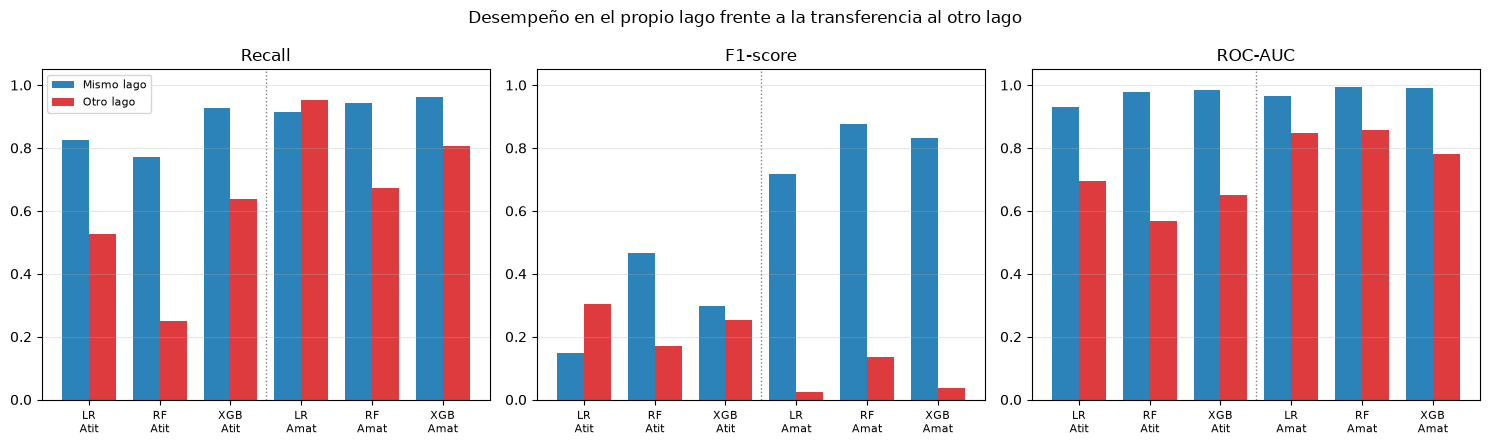

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metricas_grafico = ['Recall', 'F1-score', 'ROC-AUC']
etiquetas = ['LR', 'RF', 'XGB']
x = np.arange(len(etiquetas) * 2)

for ax, metrica in zip(axes, metricas_grafico):
    sub = df_comp[df_comp['Métrica'] == metrica]
    valores_mismo, valores_otro, ticks = [], [], []
    for lago in ['Atitlan', 'Amatitlan']:
        for nombre, etq in zip(['Regresión Logística', 'Random Forest', 'XGBoost'], etiquetas):
            r = sub[(sub['Entrenado en'] == lago) & (sub['Modelo'] == nombre)].iloc[0]
            valores_mismo.append(r['Mismo lago'])
            valores_otro.append(r['Otro lago'])
            ticks.append(f'{etq}\n{lago[:4]}')
    ancho = 0.38
    ax.bar(x - ancho/2, valores_mismo, ancho, label='Mismo lago', color='#2b83ba')
    ax.bar(x + ancho/2, valores_otro, ancho, label='Otro lago', color='#d7191c', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(ticks, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metrica)
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(2.5, color='gray', linestyle=':', linewidth=1)
    if ax is axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Desempeño en el propio lago frente a la transferencia al otro lago', fontsize=12)
plt.tight_layout()
plt.show()

**Qué muestra la comparación (7.4).** Las nueve combinaciones de modelo y dirección pierden desempeño al cambiar de lago, pero la pérdida tiene naturaleza distinta en cada dirección:

- **Atitlán como origen:** se pierde la capacidad de ordenar. El ROC-AUC baja entre 0.2339 y 0.4114 puntos y el PR-AUC entre 0.0905 y 0.4199. El modelo no logra distinguir qué píxeles de Amatitlán tienen floración.
- **Amatitlán como origen:** el ROC-AUC baja menos (entre 0.1163 y 0.2112 puntos), pero el F1 se desploma entre 0.6927 y 0.7962 puntos y el PR-AUC entre 0.4193 y 0.8616. El modelo todavía ordena bien, pero el umbral 0.5 deja de tener sentido en el lago destino.

La asimetría es informativa. Entrenar en el lago con floraciones frecuentes y de intensidades variadas produce un modelo que al menos reconoce el patrón espectral en el otro lago. Entrenar en el lago donde la clase positiva es rara, no.

Random Forest es el modelo que más se degrada en el experimento A, lo cual es coherente con su forma de funcionar: al ser el más flexible, es también el que más se ajusta a los rangos de valores propios de su lago de entrenamiento. La Regresión Logística, por ser lineal, extrapola de forma más suave y termina siendo la menos frágil en esa dirección.

## 9. Efecto de incluir las coordenadas como predictoras

Para comprobar lo anticipado en la sección 3, se repite el entrenamiento agregando `lon` y `lat` al conjunto de predictoras y se vuelve a evaluar en el otro lago. Si la transferencia empeora al incluirlas, se confirma que el modelo estaba usando la posición absoluta como atajo en lugar de aprender relaciones espectrales.

In [16]:
resultados_coord = []

for lago, clave_cruzado in [('atitlan', 'A: Atitlán -> Amatitlán'),
                            ('amatitlan', 'B: Amatitlán -> Atitlán')]:
    otro = 'amatitlan' if lago == 'atitlan' else 'atitlan'
    idx_tr = particiones[lago]['train']
    X_tr = X.loc[idx_tr, PREDICTORAS_CON_COORDENADAS]
    y_tr = y.loc[idx_tr]
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    for nombre, modelo in construir_modelos(spw).items():
        modelo.fit(X_tr, y_tr)
        idx_eval = muestras[otro]
        m = evaluar(modelo, X.loc[idx_eval, PREDICTORAS_CON_COORDENADAS], y.loc[idx_eval])
        m.update({'Experimento': clave_cruzado, 'Modelo': nombre})
        resultados_coord.append(m)
    print(f'{lago.capitalize()} con coordenadas: modelos entrenados y evaluados en {otro.capitalize()}')

df_coord = pd.DataFrame(resultados_coord).set_index(['Experimento', 'Modelo'])
print('\nTransferencia incluyendo lon y lat como predictoras:')
print(df_coord[cols_metricas].round(4).to_string())

Atitlan con coordenadas: modelos entrenados y evaluados en Amatitlan


Amatitlan con coordenadas: modelos entrenados y evaluados en Atitlan

Transferencia incluyendo lon y lat como predictoras:
                                             Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Experimento             Modelo                                                                     
A: Atitlán -> Amatitlán Regresión Logística    0.3985     0.1411  0.8600    0.2425   0.6886  0.1919
                        Random Forest          0.8874     0.3754  0.0084    0.0165   0.5925  0.1458
                        XGBoost                0.5772     0.0586  0.1845    0.0890   0.4818  0.1061
B: Amatitlán -> Atitlán Regresión Logística    0.8040     0.0392  0.7490    0.0744   0.8413  0.4292
                        Random Forest          0.9389     0.1001  0.6016    0.1716   0.8812  0.1485
                        XGBoost                0.3187     0.0144  0.9451    0.0284   0.8195  0.1345


In [17]:
comparacion_coord = pd.DataFrame({
    'Sin coordenadas': df_cruzado['ROC-AUC'],
    'Con coordenadas': df_coord['ROC-AUC'],
}).assign(Diferencia=lambda d: d['Con coordenadas'] - d['Sin coordenadas'])

comparacion_coord_recall = pd.DataFrame({
    'Sin coordenadas': df_cruzado['Recall'],
    'Con coordenadas': df_coord['Recall'],
}).assign(Diferencia=lambda d: d['Con coordenadas'] - d['Sin coordenadas'])

print('ROC-AUC en el otro lago:')
print(comparacion_coord.round(4).to_string())
print('\nRecall en el otro lago:')
print(comparacion_coord_recall.round(4).to_string())

ROC-AUC en el otro lago:
                                             Sin coordenadas  Con coordenadas  Diferencia
Experimento             Modelo                                                           
A: Atitlán -> Amatitlán Regresión Logística           0.6952           0.6886     -0.0066
                        Random Forest                 0.5676           0.5925      0.0249
                        XGBoost                       0.6502           0.4818     -0.1684
B: Amatitlán -> Atitlán Regresión Logística           0.8476           0.8413     -0.0063
                        Random Forest                 0.8585           0.8812      0.0227
                        XGBoost                       0.7810           0.8195      0.0385

Recall en el otro lago:
                                             Sin coordenadas  Con coordenadas  Diferencia
Experimento             Modelo                                                           
A: Atitlán -> Amatitlán Regresión Logística       

**Las coordenadas no ayudan a transferir.** Incluir `lon` y `lat` no mejora de forma consistente ninguna métrica y en varios casos arruina el modelo: XGBoost en el experimento A baja a ROC-AUC 0.4818, peor que el azar, y Random Forest en ese mismo experimento se queda con Recall 0.0084, es decir, deja de detectar floraciones casi por completo. Las subidas de ROC-AUC en Random Forest (+0.0249 y +0.0227) son marginales y van acompañadas de un Recall más bajo.

Esto confirma lo anticipado en la sección 3: como los rangos de `lon` y `lat` no se solapan entre lagos (el solape es de -46,840 m en longitud y -10,490 m en latitud), todas las observaciones del lago destino caen del mismo lado de cada corte aprendido, y el modelo termina aplicando a un lago entero la regla que había aprendido para una esquina del otro. Para cualquier uso entre lagos, las coordenadas absolutas deben quedar fuera del conjunto de predictoras.

## 10. Diferencias entre lagos que ayudan a explicar los resultados (7.6)

Antes de interpretar, se comparan las distribuciones de las variables predictoras y de la clase positiva en cada lago.

In [18]:
comparacion_vars = pd.DataFrame({
    'Atitlán (media)': X.loc[muestras['atitlan'], PREDICTORAS_TRANSFERIBLES].mean(),
    'Amatitlán (media)': X.loc[muestras['amatitlan'], PREDICTORAS_TRANSFERIBLES].mean(),
    'Atitlán (desv)': X.loc[muestras['atitlan'], PREDICTORAS_TRANSFERIBLES].std(),
    'Amatitlán (desv)': X.loc[muestras['amatitlan'], PREDICTORAS_TRANSFERIBLES].std(),
})
comparacion_vars['Diferencia de medias'] = (
    comparacion_vars['Amatitlán (media)'] - comparacion_vars['Atitlán (media)']
)
print('Distribución de las predictoras por lago:')
print(comparacion_vars.round(4).to_string())

Distribución de las predictoras por lago:
                  Atitlán (media)  Amatitlán (media)  Atitlán (desv)  Amatitlán (desv)  Diferencia de medias
B03                        0.0206             0.0522          0.0119            0.0410                0.0317
B08                        0.0096             0.0293          0.0110            0.0367                0.0196
NDVI                      -0.0443            -0.1427          0.1875            0.2167               -0.0984
NDWI                       0.4484             0.3678          0.1882            0.2032               -0.0805
dist_centro_lago        4729.9390          3056.7256       2147.2942         1379.2594            -1673.2135
mes_sin                    0.3589             0.6035          0.6068            0.4487                0.2446
mes_cos                   -0.1867             0.0533          0.6842            0.6570                0.2400
epoca_lluviosa             0.3046             0.0933          0.4602            0.2909

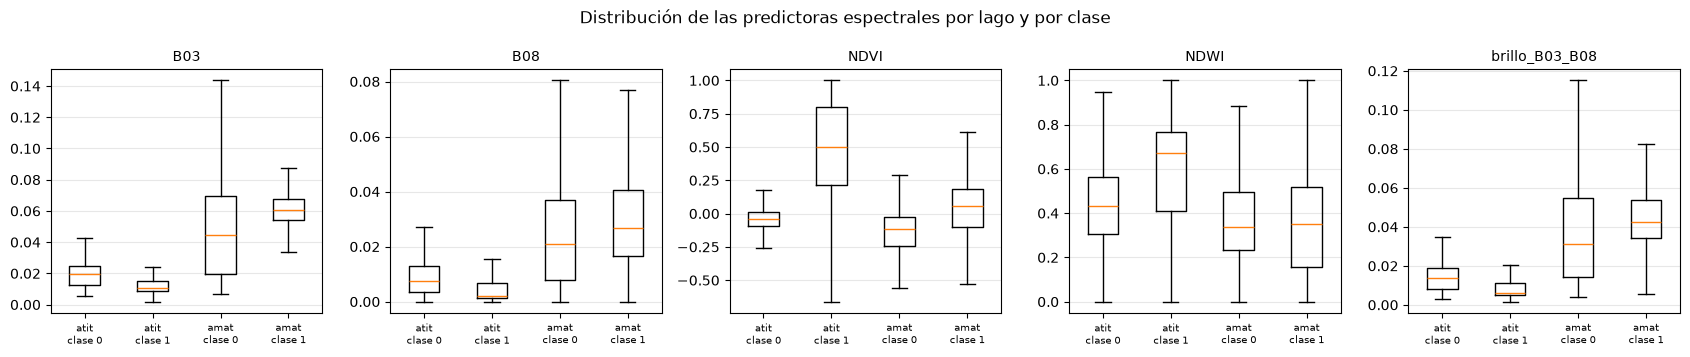

In [19]:
# Distribución de las predictoras espectrales dentro de la clase 1 en cada lago
espectrales = ['B03', 'B08', 'NDVI', 'NDWI', 'brillo_B03_B08']

fig, axes = plt.subplots(1, len(espectrales), figsize=(17, 3.6))
for ax, var in zip(axes, espectrales):
    datos = []
    etiquetas = []
    for lago in ['atitlan', 'amatitlan']:
        idx = muestras[lago]
        for clase in [0, 1]:
            sel = idx[(y.loc[idx] == clase).values]
            if len(sel) > 50000:
                sel = pd.Index(np.random.RandomState(42).choice(sel, 50000, replace=False))
            datos.append(X.loc[sel, var].values)
            etiquetas.append(f'{lago[:4]}\nclase {clase}')
    ax.boxplot(datos, tick_labels=etiquetas, showfliers=False)
    ax.set_title(var, fontsize=10)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de las predictoras espectrales por lago y por clase', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Proporción de clase 1 por fecha en cada lago
tabla_fechas = (
    pd.DataFrame({'lago': meta['lago'], 'fecha': meta['fecha'], 'y': y.values})
    .groupby(['lago', 'fecha'])['y']
    .agg(['size', 'sum', 'mean'])
    .rename(columns={'size': 'píxeles', 'sum': 'clase 1', 'mean': 'proporción clase 1'})
)
print('Proporción de clase 1 por lago y fecha:')
print(tabla_fechas.round(4).to_string())

Proporción de clase 1 por lago y fecha:
                      píxeles  clase 1  proporción clase 1
lago      fecha                                           
amatitlan 2025-01-28   148605     6647              0.0447
          2025-04-15   148229     1966              0.0133
          2025-04-28   143574     7171              0.0499
          2025-11-24   146097     7274              0.0498
          2026-01-08   138235    13005              0.0941
          2026-02-02   135775      160              0.0012
          2026-02-07   138236     1220              0.0088
          2026-03-29   148850     8200              0.0551
          2026-04-13   150724     7900              0.0524
          2026-04-28   122007    20711              0.1698
          2026-06-19   146225   101109              0.6915
atitlan   2025-01-18   301582    49629              0.1646
          2025-04-13  1226723     2231              0.0018
          2025-05-13  1227198     2239              0.0018
          2025-0

### Interpretación (7.6)

Diferencias espectrales. Los dos lagos ocupan rangos de reflectancia distintos. En Amatitlán la media de B03 es 0.0522 frente a 0.0206 en Atitlán (2.5 veces más) y la de B08 es 0.0293 frente a 0.0096 (3 veces más). El brillo medio es casi el triple y el NDVI medio es más negativo (-0.1427 frente a -0.0443). Un modelo entrenado en Atitlán encuentra en Amatitlán valores que durante su entrenamiento eran atípicos, y los árboles solo pueden extrapolar con el corte más extremo que aprendieron. Este desplazamiento de las distribuciones es la explicación más directa del fracaso del experimento A. La diferencia de fondo es física: Atitlán es un lago profundo de aguas relativamente claras y Amatitlán es somero, turbio y con carga de sedimentos y nutrientes.

La relación entre las bandas y la clase se invierte. El gráfico de cajas anterior muestra el punto más problemático para la transferencia. En Atitlán los píxeles de clase 1 tienen B03, B08 y brillo **más bajos** que los de clase 0, y se distinguen sobre todo por un NDVI y un NDWI mucho más altos. En Amatitlán ocurre lo contrario en las bandas: la clase 1 tiene B03, B08 y brillo **más altos** que la clase 0, y el NDVI apenas se separa entre clases. Es decir, la regla que asocia reflectancia con floración tiene signo distinto en cada lago. Un modelo que aprendió en un lago que menor brillo indica floración necesariamente se equivoca al aplicarlo donde ocurre lo contrario, y eso explica por qué el experimento A queda tan cerca del azar pese a usar exactamente las mismas variables.

Diferencias de prevalencia. Amatitlán tiene 11.19 % de píxeles de clase 1 y Atitlán 1.05 %, más de 10 a 1. Los pesos de clase se calculan sobre el lago de origen (`scale_pos_weight` de 94.03 en Atitlán frente a 7.93 en Amatitlán), así que la probabilidad que produce cada modelo está calibrada para la prevalencia de su lago. Al cambiar de lago, el umbral 0.5 deja de corresponder al mismo punto de operación, que es justamente lo que se observa en el experimento B.

Diferencias en la calidad de la señal de entrenamiento. En Amatitlán la proporción de clase 1 por fecha va de 0.12 % a 69.15 %, así que el modelo ve floraciones reales de intensidades muy distintas. En Atitlán casi el 40 % de los positivos vienen de una sola fecha, 2025-01-18 (49,629 de 125,726 píxeles positivos), señalada en los notebooks anteriores como posible artefacto numérico del NDCI en aguas muy claras, y otro 27 % de 2025-11-21. Un modelo entrenado en Atitlán aprende en buena parte ese comportamiento puntual y no una firma general de floración, lo que explica que reconozca tan mal las floraciones de Amatitlán.

Diferencias geográficas y morfológicas. Atitlán aporta 11.9 millones de píxeles de agua y Amatitlán 1.57 millones, y la distancia media al centro del lago es de 4,730 m frente a 3,057 m. Aunque `dist_centro_lago` es una medida relativa, no significa lo mismo en ambos: 3 km desde el centro en Amatitlán ya es prácticamente la orilla, mientras que en Atitlán sigue siendo agua abierta.

Diferencias temporales. Las fechas disponibles no coinciden entre lagos y su reparto estacional tampoco: 30.5 % de los píxeles de Atitlán corresponden a época lluviosa frente a 9.3 % en Amatitlán. Las variables de estacionalidad quedan por lo tanto asociadas a valores distintos en cada lago, lo que añade otra fuente de desplazamiento al transferir el modelo.

## 11. ¿Puede un modelo entrenado en un lago generalizar al otro? (7.5)

No con la configuración actual. Ninguna de las dos direcciones alcanza un desempeño utilizable de forma directa en el lago destino:

- **Atitlán hacia Amatitlán:** el mejor ROC-AUC es 0.6952 y el mejor PR-AUC 0.2205 sobre una línea base de 0.1119. El modelo apenas mejora al azar, así que no sirve como herramienta de monitoreo.
- **Amatitlán hacia Atitlán:** el mejor ROC-AUC es 0.8585 y el mejor PR-AUC 0.4349 sobre una línea base de 0.0105. Aquí sí queda señal aprovechable, pero con umbral 0.5 la Precision no pasa de 0.0757, es decir, más de 12 falsas alarmas por cada detección correcta.

Frente al desempeño dentro del mismo lago (ROC-AUC de 0.9791 en Atitlán y 0.9936 en Amatitlán con Random Forest), la pérdida es grande en las dos direcciones.

La transferencia desde Amatitlán conserva la capacidad de ordenar los píxeles por riesgo aunque pierda el punto de corte. Eso deja abierta una vía práctica: usar ese modelo como filtro grueso en Atitlán recalibrando el umbral con datos del lago destino, por ejemplo fijándolo en el cuantil que corresponde a la prevalencia esperada en lugar de en 0.5. Lo que no es viable es aplicar el modelo tal cual.

**Recomendación.** Entrenar un modelo por lago, o entrenar un modelo conjunto con datos de ambos como el de los notebooks 04 y 05, y en todo caso ajustar el umbral por lago. Si se quisiera aplicar el modelo a un tercer cuerpo de agua sin datos etiquetados, lo esperable según estos resultados es un desempeño entre el del experimento A y el del B, por lo que haría falta al menos una campaña de validación local antes de usarlo de forma operativa.

Este resultado también refuerza la conclusión del notebook 06: cuanto más lejos está el conjunto de evaluación del de entrenamiento, en el espacio geográfico y en el de las variables, más baja el desempeño. La partición aleatoria del notebook 04 es la estimación más optimista, la validación espacial por bloques es intermedia y la transferencia entre lagos es la más exigente y la más parecida a aplicar el modelo en un lugar nuevo.

## 12. Guardado de resultados

In [21]:
df_todo = pd.concat([
    df_cruzado.assign(Conjunto='predictoras transferibles'),
    df_mismo.assign(Conjunto='predictoras transferibles'),
    df_coord.assign(Conjunto='con lon y lat'),
])
df_todo.to_csv('./data/resultados_generalizacion_lagos.csv')
df_comp.to_csv('./data/comparacion_mismo_lago_vs_otro.csv', index=False)

print('Guardado:')
print('  ./data/resultados_generalizacion_lagos.csv')
print('  ./data/comparacion_mismo_lago_vs_otro.csv')

Guardado:
  ./data/resultados_generalizacion_lagos.csv
  ./data/comparacion_mismo_lago_vs_otro.csv
